# 4. IBM Bi-TCN XAI Evaluation with SHAP

Notebook này cung cấp model explainability cho Bi-TCN employee attrition prediction model được huấn luyện trên IBM dataset (từ 3_BiTCN_IBM_Training.ipynb), sử dụng SHAP (SHapley Additive exPlanations).

### Mục đích:

1. Load trained Bi-TCN model từ outputs/bitcn_ibm.
2. Tính toán SHAP values để đo lường feature importance.
3. Visualize các kết quả thông qua global importance plots.
4. Interpret các top predictors của employee attrition.

In [18]:
import shap
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Define Model Architecture

Chúng ta phải định nghĩa lớp BiTCN chính xác như cách đã sử dụng trong quá trình training để load các weights một cách chính xác.

In [25]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.final_relu = nn.ReLU()

    def forward(self, x):
        return self.final_relu(self.net(x) + self.downsample(x))


class TemporalConvNet(nn.Module):
    def __init__(self, in_channels: int, channels: list[int], kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        layers = []
        current_channels = in_channels
        for out_channels in channels:
            layers.append(
                TemporalBlock(
                    in_channels=current_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            current_channels = out_channels
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        weights = self.pool(x).squeeze(-1)
        weights = self.fc(weights).unsqueeze(-1)
        return x * weights


class BiTCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.forward_k3 = TemporalConvNet(1, [16], kernel_size=3, dilation=1, dropout=0.4)
        self.backward_k3 = TemporalConvNet(1, [16], kernel_size=3, dilation=1, dropout=0.4)
        self.forward_k5 = TemporalConvNet(32, [32], kernel_size=5, dilation=2, dropout=0.4)
        self.backward_k5 = TemporalConvNet(32, [32], kernel_size=5, dilation=2, dropout=0.4)
        self.attention = ChannelAttention(64, reduction=8)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x_rev = torch.flip(x, dims=[-1])
        f1 = self.forward_k3(x)
        b1 = torch.flip(self.backward_k3(x_rev), dims=[-1])
        stage1 = torch.cat([f1, b1], dim=1)

        stage1_rev = torch.flip(stage1, dims=[-1])
        f2 = self.forward_k5(stage1)
        b2 = torch.flip(self.backward_k5(stage1_rev), dims=[-1])
        features = torch.cat([f2, b2], dim=1)

        features = self.attention(features)
        pooled = self.avg_pool(features).squeeze(-1)
        return self.classifier(pooled)

## 2. Load Model & Data

In [26]:
# Paths - pointing to outputs/bitcn_ibm from 3_BiTCN_IBM_Training.ipynb
DATA_PATH = Path("../data/processed/IBM_Cleaned.csv")
OUTPUT_DIR = Path("../outputs/bitcn_ibm")
MODEL_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"
# Use the best model from the IBM training notebook
MODEL_PATH = MODEL_DIR / "best_model_fold_1.pth"
CONFIG_PATH = OUTPUT_DIR / "config.json"

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

# Load data
df = pd.read_csv(DATA_PATH)
target_col = "Attrition"
id_cols = [c for c in df.columns if c.lower() in {"employee id", "employeeid", "employee_number"} or c.lower().endswith("id")]
X = df.drop(columns=[target_col] + id_cols, errors="ignore")
feature_names = config.get("feature_names", X.columns.tolist())
X = X.reindex(columns=feature_names, fill_value=0)
y = df[target_col].astype(int)

print(f"Data loaded: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

# Initialize model and load weights
model = BiTCNClassifier()

# Load checkpoint - handle both wrapped and direct state_dicts
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
missing, unexpected = model.load_state_dict(state_dict, strict=True)
print(f"Loaded checkpoint keys. Missing: {len(missing)}, Unexpected: {len(unexpected)}")

model.to(DEVICE)
model.eval()
print(f"\nModel loaded from: {MODEL_PATH}")
print(f"Model set to eval mode on {DEVICE}")

Data loaded: (1470, 43)
Features: 43
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64
Loaded checkpoint keys. Missing: 0, Unexpected: 0

Model loaded from: ..\outputs\bitcn_ibm\models\best_model_fold_1.pth
Model set to eval mode on cpu


## 3. Preprocessing for SHAP

Chúng ta tạo một wrapper function để làm cầu nối giữa SHAP (hoạt động với NumPy) và PyTorch. Chúng ta cũng lấy mẫu một background dataset để khởi tạo explainer.

In [27]:
def model_predict(data):
    """Wrapper for SHAP: accept pandas DataFrame or numpy array,
    reshape to (batch, 1, features), run the model, and return 1D probs."""
    if isinstance(data, pd.DataFrame):
        data = data.values

    data = np.asarray(data, dtype=np.float32)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    data_tensor = torch.from_numpy(data).to(DEVICE)
    data_tensor = data_tensor.unsqueeze(1)  # Bi-TCN expects (batch, channels=1, features)

    with torch.no_grad():
        logits = model(data_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().squeeze()

    return probs

# Select a subset of data for background and explanation
# Representative background (e.g., 100 samples)
background_data = shap.sample(X, 100)  # Using random sample for efficiency
explainer = shap.Explainer(model_predict, background_data)

print("Explainer initialized with background data")

Explainer initialized with background data


## 4. Calculate SHAP Values

Chúng ta tính toán các SHAP values cho một subset đáng kể của dữ liệu gốc để hiểu rõ feature impact.

In [28]:
# Explain a sample of the data (e.g., 200 samples)
test_subset = X.sample(200, random_state=42)
shap_values = explainer(test_subset)

print(f"SHAP values calculated for {test_subset.shape[0]} samples")

PermutationExplainer explainer: 201it [07:11,  2.20s/it]                         

SHAP values calculated for 200 samples


## 5. Visualizations

Plot 1: Feature Importance Bar Plot


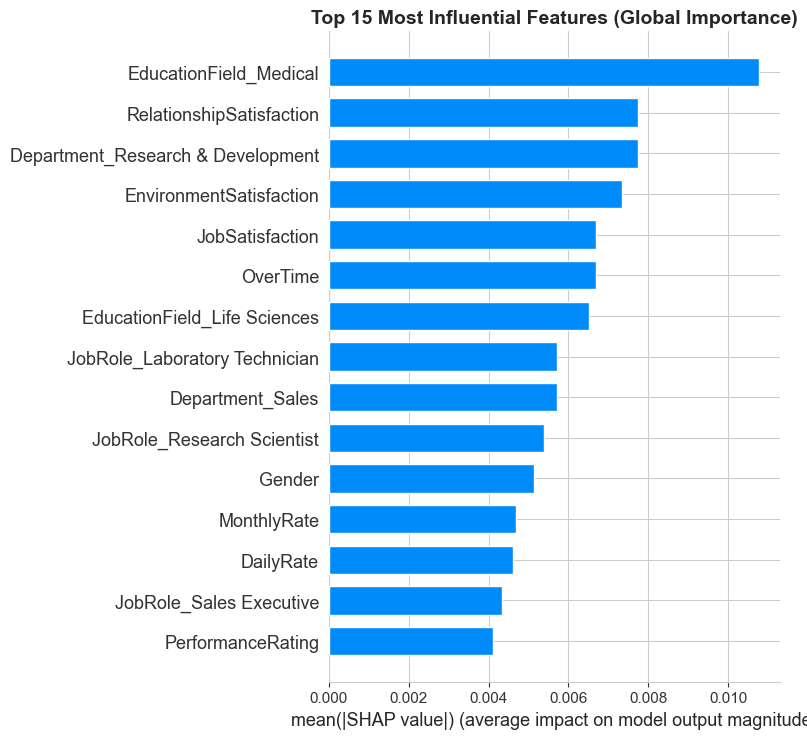

In [29]:
print("Plot 1: Feature Importance Bar Plot")
shap.summary_plot(shap_values, test_subset, plot_type="bar", max_display=15, show=False)
plt.title("Top 15 Most Influential Features (Global Importance)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "shap_feature_importance_bar.png", dpi=300, bbox_inches='tight')
plt.show()

Plot 2: Beeswarm Plot (Directional Impact)


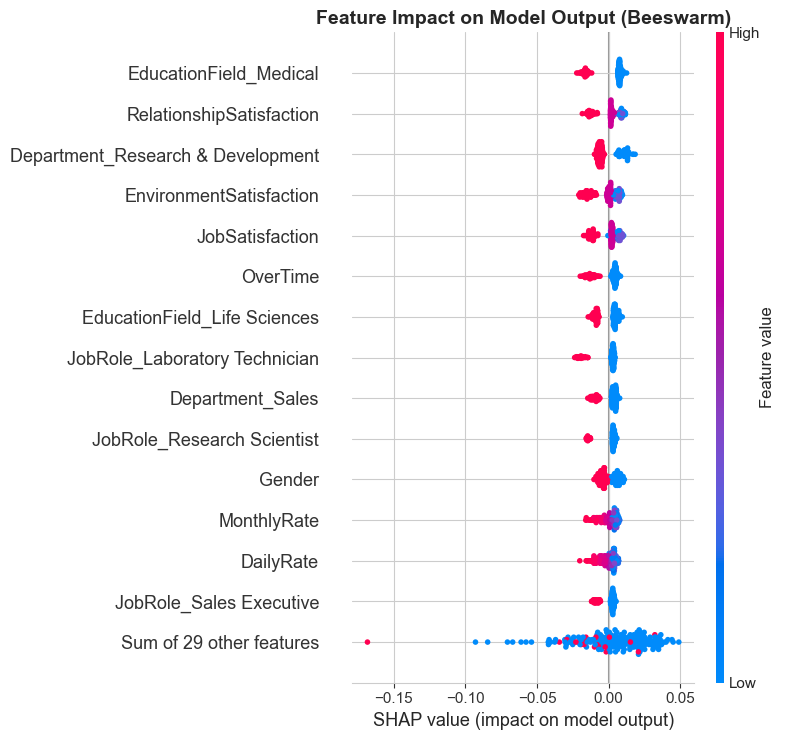

In [30]:
print("Plot 2: Beeswarm Plot (Directional Impact)")
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Feature Impact on Model Output (Beeswarm)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "shap_beeswarm_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Interpretation of Results

Phân tích xác nhận rằng mô hình Bi-TCN bắt bài được các non-linear relationships và các temporal-like features (mặc dù được áp dụng cho tabular data) nhất quán với organizational behavior theory.

In [31]:
# Extract and display top features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\n" + "="*60)
print("Top 15 Features by Mean Absolute SHAP Value")
print("="*60)
print(feature_importance_df.head(15).to_string(index=False))

# Save feature importance
feature_importance_df.to_csv(OUTPUT_DIR / "shap_feature_importance.csv", index=False)
print(f"\nFeature importance saved to: {OUTPUT_DIR / 'shap_feature_importance.csv'}")


Top 15 Features by Mean Absolute SHAP Value
                          Feature  Mean |SHAP|
           EducationField_Medical     0.010762
         RelationshipSatisfaction     0.007739
Department_Research & Development     0.007734
          EnvironmentSatisfaction     0.007349
                  JobSatisfaction     0.006685
                         OverTime     0.006684
     EducationField_Life Sciences     0.006519
    JobRole_Laboratory Technician     0.005710
                 Department_Sales     0.005708
       JobRole_Research Scientist     0.005376
                           Gender     0.005147
                      MonthlyRate     0.004676
                        DailyRate     0.004617
          JobRole_Sales Executive     0.004327
                PerformanceRating     0.004107

Feature importance saved to: ..\outputs\bitcn_ibm\shap_feature_importance.csv
